# Sprint 6 - Análisis Exploratorio Inferencial (Sesiones)

En este caso profundizaremos en dos de los conceptos más importantes de la estadística inferencial y del análisis de datos aplicado a la toma de decisiones: las **pruebas de hipótesis** y los **intervalos de confianza**.El objetivo de estas herramientas consiste en determinar si la evidencia disponible en una muestra permite respaldar o rechazar una afirmación sobre una población. Gracias a este enfoque, es posible diferenciar entre cambios que se deben simplemente al azar y cambios que probablemente son consecuencia de una acción, intervención o fenómeno específico.

Para comprender mejor su aplicación práctica, trabajaremos con un tipo de estudio ampliamente utilizado en empresas que basan sus decisiones en información: las **Pruebas A/B**. Estas pruebas constituyen una metodología experimental efectiva cuyo propósito es evaluar si una modificación específica produce cambios medibles sobre un o varios indicadores de interés.

La lógica detrás de las pruebas A/B es relativamente sencilla. En primera instancia se divide a una población de entidades (i.e, clientes, productos, empleados, etc.) en dos grupos. Un grupo llamado de control o referencia, mantiene las condiciones habituales o existentes antes del experimento. Por su parte, un grupo de tratamiento o de investigación, recibe la modificación o intervención que se desea evaluar. Posteriormente, se comparan los resultados obtenidos por ambos grupos para determinar si las diferencias observadas son suficientemente significativas desde un punto de vista estadístico.

La simplicidad conceptual de las pruebas A/B no debe llevarnos a subestimar la importancia de un diseño experimental adecuado. De hecho, la calidad de las conclusiones obtenidas dependerá en gran medida de cómo se estructura y ejecuta el experimento. Un diseño deficiente puede conducir a resultados sesgados o interpretaciones incorrectas, independientemente de la sofisticación de las técnicas estadísticas utilizadas posteriormente.

En este sentido, es fundamental que exista una clara separación entre los grupos de control y tratamiento. Así también, resulta indispensable que la única diferencia relevante entre ambos grupos sea precisamente el factor que se desea evaluar. Si existen otros elementos que cambian simultáneamente durante el experimento, será difícil determinar cuál de ellos es realmente responsable de los resultados observados.

El tamaño de la muestra juega un papel determinante en la inferencia estadística, y por tanto lo hará de igual forma en una prueba A/B. Si el número de observaciones es demasiado pequeño, pueden existir diferencias reales entre los grupos que pasen desapercibidas debido a la variabilidad natural de los datos. Del mismo modo, un desequilibrio excesivo entre el tamaño de los grupos puede afectar la precisión de las estimaciones y la potencia estadística del análisis. 

A lo largo de este caso práctico aprenderemos entonces cómo diseñar experimentos sencillos bajo estos criterios, y practicar nuestra formulación de hipótesis estadísticas, para posteriormente aplicar pruebas inferenciales e interpretar correctamente sus resultados. De esta manera, incorporaremos una de las herramientas más utilizadas en la actualidad para la toma de decisiones basada en evidencia.

## Entendimiento el contexto

Una empresa que ofrece servicios de *call-center* enfrenta una situación delicada relacionada con la gestión de su talento humano. Durante una revisión periódica de indicadores operativos, la gerencia de operaciones detectó que uno de los agentes presenta registros que sugieren un posible incumplimiento recurrente de su jornada laboral. De acuerdo con los reportes preliminares, el tiempo efectivo de trabajo del colaborador sería inferior al esperado según las políticas internas de la organización. Como consecuencia, algunos directivos han planteado la posibilidad de proceder con su desvinculación, argumentando que este comportamiento afecta la productividad del equipo y genera una carga adicional sobre otros trabajadores.

Sin embargo, debido a los costos asociados a una terminación laboral de esta naturaleza, la dirección de la empresa ha decidido realizar una investigación más exhaustiva antes de adoptar cualquier medida. Además del impacto financiero que puede representar un despido, la organización es consciente de que una decisión incorrecta podría afectar el clima laboral y transmitir una señal negativa al resto de colaboradores. Por esta razón, se ha optado por brindar al trabajador la oportunidad de presentar sus argumentos y evidencias antes de emitir una resolución definitiva.

Durante la reunión de descargo, el operador cuestiona las conclusiones obtenidas por la gerencia y sostiene que los indicadores utilizados no reflejan adecuadamente su desempeño real. Según su versión, aunque podría registrar menos tiempo de conexión al sistema de gestión de clientes (CRM) que otros compañeros en determinados momentos, su nivel de concentración y productividad durante las horas efectivamente trabajadas es considerablemente superior. En particular, argumenta que mantiene una conexión más estable a dicho sistema, evitando interrupciones frecuentes y reduciendo tiempos improductivos que sí estarían presentes en otros miembros del equipo.

Adicionalmente, el trabajador afirma que su desempeño operativo supera al promedio de la organización. Como evidencia de ello, señala que su tasa de llamadas completadas o correctamente atendidas es superior a la observada en otros agentes, lo que le permitiría generar más valor para la empresa aun cuando sus patrones de conexión difieran de los estándares tradicionales. Desde su perspectiva, la evaluación debería centrarse en los resultados obtenidos y no únicamente en el tiempo registrado dentro de la plataforma de trabajo.

Ante la dificultad de determinar objetivamente cuál de las dos posiciones refleja con mayor precisión la realidad, el departamento de recursos humanos ha decidido recurrir al análisis de datos para respaldar su proceso de toma de decisiones. Para ello, te ha contratado con el objetivo de analizar la evidencia disponible y determinar si las diferencias observadas son estadísticamente significativas. Utilizando técnicas de inferencia estadística y pruebas A/B, deberás evaluar si el desempeño del colaborador realmente difiere del resto de operadores y si sus argumentos cuentan con suficiente respaldo cuantitativo. Los resultados de tu análisis servirán como base para que la empresa adopte una decisión justa, objetiva y sustentada en evidencia.

## Entendimiento de datos

Importa las librerías y módulos con los que trabajarás.

In [1]:
library(tidyverse)
library(readxl)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


A continuación, carga los datos que te proporciona la empresa y con los cuales desarrollarás tus análisis. Estos datos se encuentran en el archivo [**employee_data.xlsx**](https://github.com/jsaraujo5081/material_curso_data_analytics/raw/refs/heads/main/datasets/employee_data.xlsx). Considera para esto que el archivo cuenta con dos pestañas (*Emp 1* y *Emp 2*), y que deberás cargar la información de cada una en dos datasets distintos.

In [2]:
# Cargar datos de Emp 1
temp_file <- tempfile(fileext = ".xlsx")
download.file("https://github.com/jsaraujo5081/material_curso_data_analytics/raw/refs/heads/main/datasets/employee_data.xlsx", temp_file, mode = "wb")
df_emp1 <- read_excel(temp_file, sheet = "Emp 1")

# Mirar estructura de los datos
glimpse(df_emp1)

Rows: 50
Columns: 4
$ Day                     <chr> "Monday", "Monday", "Monday", "Monday", "Monda…
$ Hour                    <dbl> 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 8, 9, 10…
$ `Minutes Active in CRM` <dbl> 22, 25, 16, 28, 18, 11, 24, 40, 31, 23, 33, 31…
$ `Completed Calls Rate`  <dbl> 0.3151650, 0.8900000, 0.8000000, 0.5785775, 0.…


In [3]:
# Cargar datos de Emp 2
df_emp2 <- read_excel(temp_file, sheet = "Emp 2")

# Mirar estructura de los datos
glimpse(df_emp2)

Rows: 50
Columns: 4
$ Day                     <chr> "Monday", "Monday", "Monday", "Monday", "Monda…
$ Hour                    <dbl> 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 8, 9, 10…
$ `Minutes Active in CRM` <dbl> 36, 23, 39, 39, 22, 20, 37, 37, 54, 39, 52, 35…
$ `Completed Calls Rate`  <dbl> 0.72000000, 0.72859918, 0.30566326, 0.81951382…


La tabla en la pestaña *Emp 1* corresponde a información de la última semana del empleado investigado respecto a lo siguiente: 

* Day: Día de la semana en la que se tomaron los datos. 
* Hour: Hora del día en la que se tomaron los datos.
* Minutes Active in CRM: Minutos totales en dicha hora y día en los que el sistema reflejó actividad por parte del empleado.
* Completed Calls Rate: Porcentaje de llamadas debidamente completadas por parte del empleado respecto al total que atendió duante esa hora y día.

Explora este dataset generando una muestra del mismo, verificando si existen valores perdidos, mostrando los valores únicos de día y hora, y mostrando también un resumen estadístico de los indicadores existentes. 

In [4]:
# Generar muestra de datos
df_emp1 %>% sample_n(10)

Day,Hour,Minutes Active in CRM,Completed Calls Rate
<chr>,<dbl>,<dbl>,<dbl>
Wednesday,14,28,0.6987953
Thursday,16,33,0.8700000
Tuesday,13,13,0.8500000
Monday,14,24,0.4609026
Monday,13,11,0.8312548
Thursday,10,28,0.8300000
Friday,16,19,0.3136105
Wednesday,10,27,0.8300000
Friday,9,19,0.8100000


In [5]:
# Verificar si existen valores perdidos
print(colSums(is.na(df_emp1)))

                  Day                  Hour Minutes Active in CRM 
                    0                     0                     0 
 Completed Calls Rate 
                    0 


In [6]:
# Mostrar valores unicos de dia
df_emp1 %>%
count(Day)

Day,n
<chr>,<int>
Friday,10
Monday,10
Thursday,10
Tuesday,10
Wednesday,10


In [7]:
# Mostrar valores unicos de hora
df_emp1 %>%
count(Hour)

Hour,n
<dbl>,<int>
8,5
9,5
10,5
11,5
12,5
13,5
14,5
15,5
16,5


In [8]:
# Visualizar distribucion de minutos y tasa de completitud
df_emp1[c("Minutes Active in CRM", "Completed Calls Rate")] %>% summary()

 Minutes Active in CRM Completed Calls Rate
 Min.   : 0.00         Min.   :0.1903      
 1st Qu.:22.25         1st Qu.:0.6473      
 Median :28.50         Median :0.8013      
 Mean   :26.90         Mean   :0.7105      
 3rd Qu.:33.00         3rd Qu.:0.8300      
 Max.   :40.00         Max.   :0.9000      

Por su parte, la tabla en la pestaña *Emp 2* contiene la misma información promedio del equipo de operadores del call-center para la última semana.

Explora esta información generando los mismos resultados que antes.

In [9]:
# Generar muestra de datos
df_emp2 %>% sample_n(10)

Day,Hour,Minutes Active in CRM,Completed Calls Rate
<chr>,<dbl>,<dbl>,<dbl>
Tuesday,15,34,0.4289445
Wednesday,16,46,0.8500000
Wednesday,12,44,0.7695471
Friday,14,23,0.1969349
Tuesday,14,33,0.3713358
Thursday,8,43,0.2309709
Wednesday,9,31,0.4683227
Friday,13,16,0.3038744
Friday,16,30,0.3320059


In [10]:
# Verificar si existen valores perdidos
print(colSums(is.na(df_emp2)))

                  Day                  Hour Minutes Active in CRM 
                    0                     0                     0 
 Completed Calls Rate 
                    0 


In [11]:
# Mostrar valores unicos de dia
df_emp1 %>%
count(Day)

Day,n
<chr>,<int>
Friday,10
Monday,10
Thursday,10
Tuesday,10
Wednesday,10


In [12]:
# Mostrar valores unicos de hora
df_emp1 %>%
count(Hour)

Hour,n
<dbl>,<int>
8,5
9,5
10,5
11,5
12,5
13,5
14,5
15,5
16,5


In [13]:
# Visualizar distribucion de minutos y tasa de completitud
df_emp2[c("Minutes Active in CRM", "Completed Calls Rate")] %>% summary()

 Minutes Active in CRM Completed Calls Rate
 Min.   :10.00         Min.   :0.01853     
 1st Qu.:30.00         1st Qu.:0.33867     
 Median :37.00         Median :0.47166     
 Mean   :36.52         Mean   :0.52071     
 3rd Qu.:44.75         3rd Qu.:0.72965     
 Max.   :55.00         Max.   :0.85000     

A partir de este conocimiento, genera un plan de acción para preparar estos datos.

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

| # | Acción |
| ---- | ---- |
| 1 | Incorporar en cada dataset una columna que identifique al empleado que corresponda. |
| 2 | Concatenar los datasets para tener una sola fuente de información con la que ejecutar los análisis posteriores. |
| 3 | Cambiar los nombres de la tabla para que se encuentre en formato snake_case. |
| 4 | Incorporar una columna con el día de la semana en formato numerico para mayor facilidad de ordenamiento en el análisis. |

## Preparación de datos

Ejecuta el plan de acción antes definido.

In [14]:
# Incorporar columna de identificacion del empleado en empleado 1
df_emp1 <- df_emp1 %>%
mutate(employee = "investigated")

# Incorporar columna de identificacion del empleado en empleado 2
df_emp2 <- df_emp2 %>%
mutate(employee = "reference")

In [15]:
# Concatenar datasets
df_consolidado <- df_emp1 %>%
bind_rows(df_emp2)

glimpse(df_consolidado)

Rows: 100
Columns: 5
$ Day                     <chr> "Monday", "Monday", "Monday", "Monday", "Monda…
$ Hour                    <dbl> 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 8, 9, 10…
$ `Minutes Active in CRM` <dbl> 22, 25, 16, 28, 18, 11, 24, 40, 31, 23, 33, 31…
$ `Completed Calls Rate`  <dbl> 0.3151650, 0.8900000, 0.8000000, 0.5785775, 0.…
$ employee                <chr> "investigated", "investigated", "investigated"…


In [16]:
# Cambiar nombres de columna
names(df_consolidado) <- names(df_consolidado) %>%
tolower() %>%
gsub(" ","_", .)

print(names(df_consolidado))

[1] "day"                   "hour"                  "minutes_active_in_crm"
[4] "completed_calls_rate"  "employee"             


In [17]:
# Incorporar columna que contenga dias de la semana en formato numero
dic_days = tibble(
    day = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday"),
    nday = 1:5
)

df_consolidado <- df_consolidado %>%
left_join(
    dic_days,
    by = "day"
) %>%
mutate(dayhour = paste(sprintf("%02d",nday),"-",sprintf("%02d",hour), sep = ""))

df_consolidado %>% sample_n(10)

day,hour,minutes_active_in_crm,completed_calls_rate,employee,nday,dayhour
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
Wednesday,8,37,0.82000000,investigated,3,03-08
Tuesday,16,31,0.81000000,investigated,2,02-16
Wednesday,17,32,0.28485790,investigated,3,03-17
Tuesday,13,13,0.85000000,investigated,2,02-13
Monday,14,37,0.24416894,reference,1,01-14
Friday,8,50,0.42880167,reference,5,05-08
Wednesday,17,48,0.01852822,reference,3,03-17
Tuesday,9,31,0.71910147,investigated,2,02-09
Wednesday,16,33,0.82673952,investigated,3,03-16


## Análisis exploratorio descriptivo

Procedamos estudiando en mayor detalle el comportamiento de los indicadores de interés. Dado que por el contexto nos interesa analizar la centralidad y la dispersión de los minutos activos de los empleados, muestra la media y la desviación estandar de la variable tanto para el empleado investigado como para el caso referencial.

In [18]:
df_consolidado %>%
group_by(employee) %>%
summarise(
    mean = mean(minutes_active_in_crm),
    std = sd(minutes_active_in_crm)
) %>%
ungroup()

employee,mean,std
<chr>,<dbl>,<dbl>
investigated,26.90,8.899094
reference,36.52,11.364535


Para mirar en más detalle esta información, compara las distribuciones de minutos de ambos grupos mediante gráficas de cajón con bigote. 

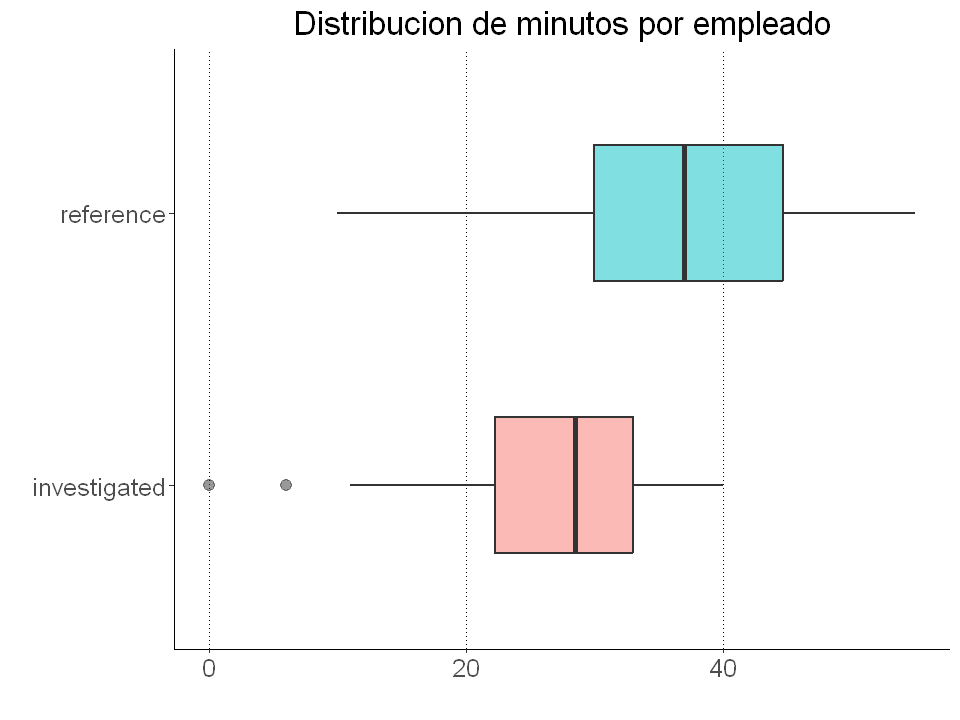

In [19]:
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(
    data = df_consolidado,
    mapping = aes(
        x = minutes_active_in_crm,
        y = employee,
        fill = employee
    )
) +
geom_boxplot(
    width = 0.5,
    alpha = 0.5,
    show.legend = FALSE,
    outlier.size = 3,
    linewidth = 0.75
) +
labs(
    title = "Distribucion de minutos por empleado",
    x = "",
    y = ""
) +
theme_classic() +
theme(
    panel.grid.major.x = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

Complementa esta comparación con gráficas de densidad.

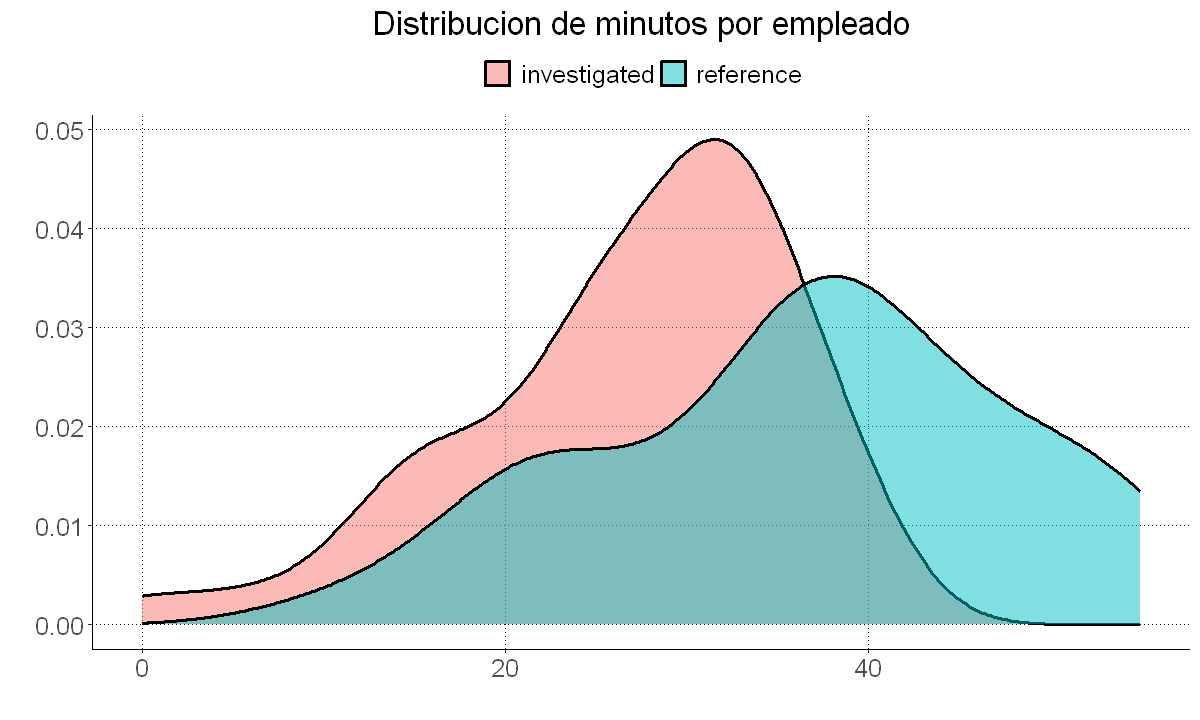

In [20]:
options(repr.plot.width = 10, repr.plot.height = 6)
ggplot(
    data = df_consolidado,
    mapping = aes(
        x = minutes_active_in_crm,
        fill = employee
    )
) +
geom_density(
    linewidth = 1,
    alpha = 0.5
) +
labs(
    title = "Distribucion de minutos por empleado",
    x = "",
    y = ""
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    legend.title = element_blank(),
    legend.text = element_text(size = 15),
    legend.position = "top"
)

En vista que esta información se encuentra distribuida a través del tiempo, igualmente has una comparación de los minutos de actividad por grupo de empleado mediante una evolución durante la semana de análisis.

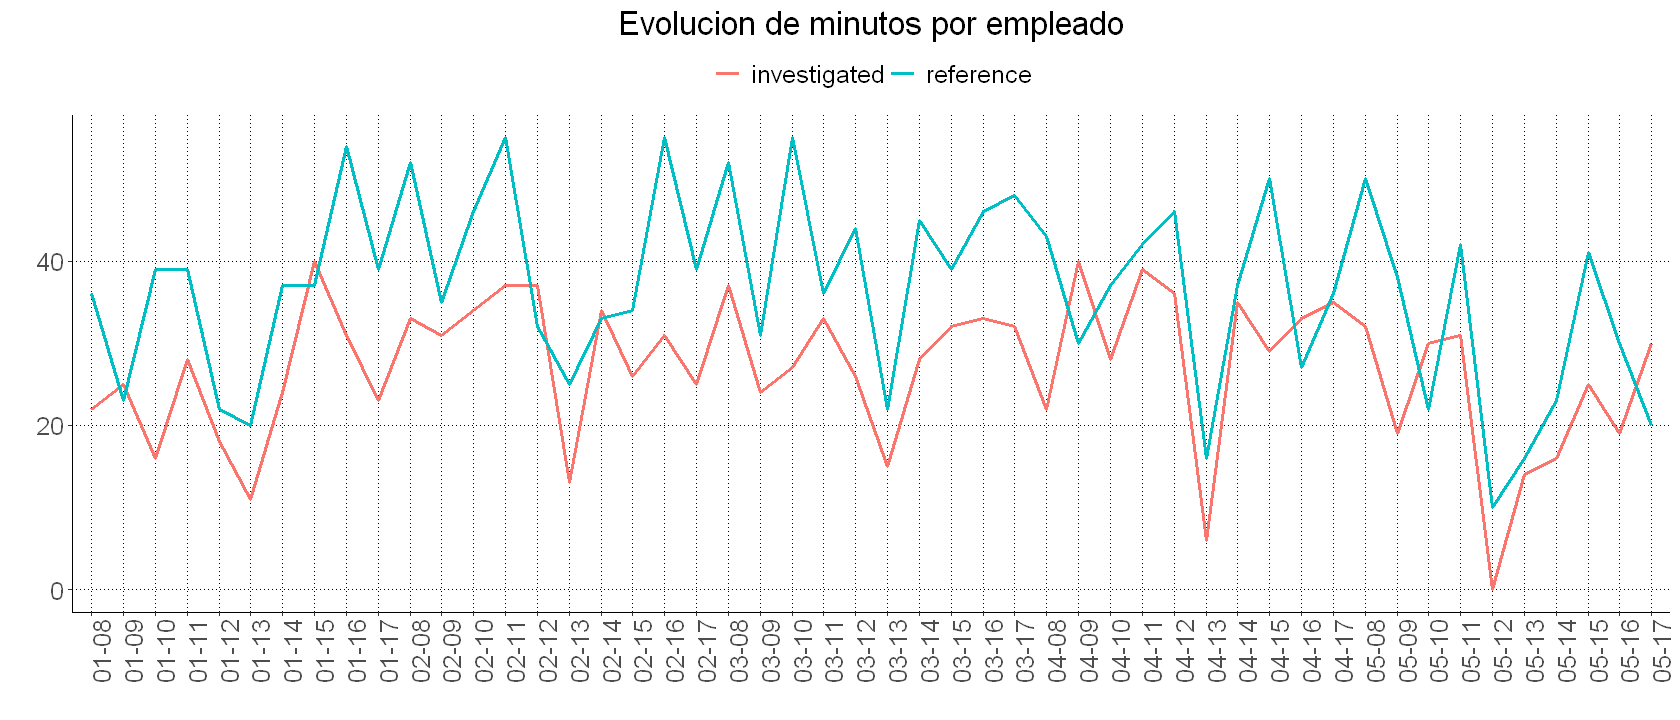

In [21]:
options(repr.plot.width = 14, repr.plot.height = 6)
ggplot(
    data = df_consolidado,
    mapping = aes(
        x = reorder(dayhour, nday),
        y = minutes_active_in_crm,
        color = employee,
        group = employee
    )
) +
geom_line(
    linewidth = 1
) +
labs(
    title = "Evolucion de minutos por empleado",
    x = "",
    y = ""
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.text.x = element_text(angle = 90),
    axis.title = element_text(size = 15),
    legend.title = element_blank(),
    legend.text = element_text(size = 15),
    legend.position = "top"
)

En base a estos resultados, existirían indicios que en efecto el empleado investigado tiene menor tiempo de trabajo que los demás, aunque su tiempo de trabajo sería más estable (menos volatil).

Procedamos ahora a estudiar el indicador de tasa de completitud de llamadas. Al igual que antes extrae el promedio y la desviación estandar de este indicador por grupo de empleado.

In [22]:
df_consolidado %>%
group_by(employee) %>%
summarise(
    mean = mean(completed_calls_rate),
    std = sd(completed_calls_rate)
) %>%
ungroup()

employee,mean,std
<chr>,<dbl>,<dbl>
investigated,0.7104604,0.1933870
reference,0.5207149,0.2421615


Procede con una comparativa visual de la ditribución de estas variables a través de cajones con bigotes.

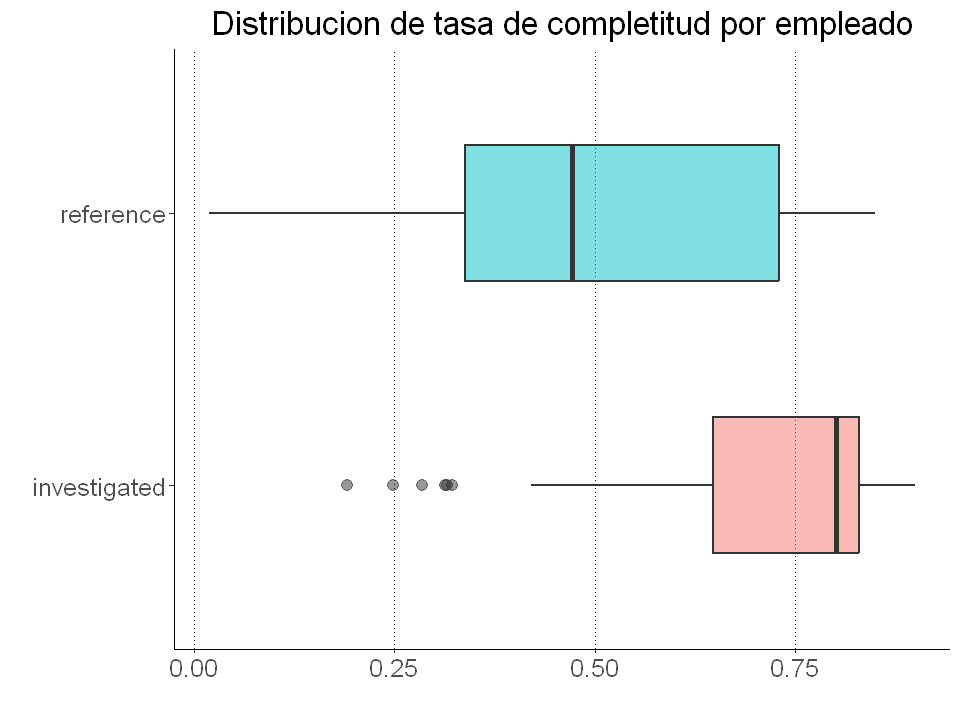

In [23]:
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(
    data = df_consolidado,
    mapping = aes(
        x = completed_calls_rate,
        y = employee,
        fill = employee
    )
) +
geom_boxplot(
    width = 0.5,
    alpha = 0.5,
    show.legend = FALSE,
    outlier.size = 3,
    linewidth = 0.75
) +
labs(
    title = "Distribucion de tasa de completitud por empleado",
    x = "",
    y = ""
) +
theme_classic() +
theme(
    panel.grid.major.x = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

Complementa tu análisis comparativo con unas gráficas de densidad.

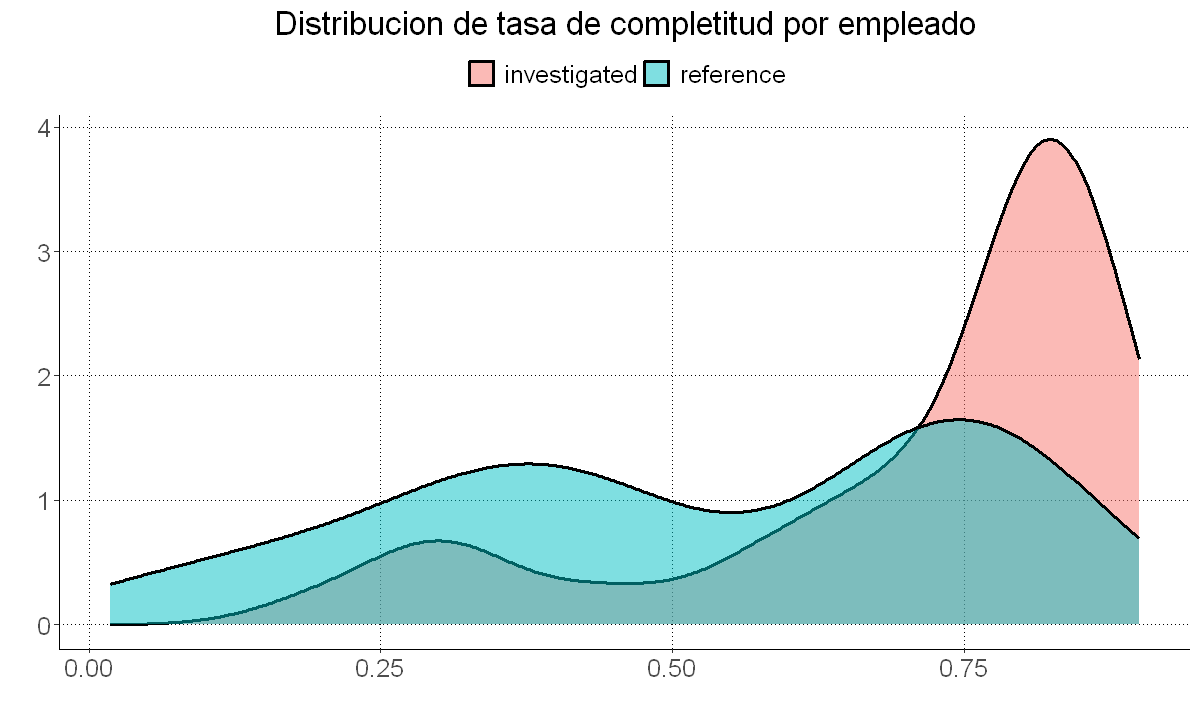

In [24]:
options(repr.plot.width = 10, repr.plot.height = 6)
ggplot(
    data = df_consolidado,
    mapping = aes(
        x = completed_calls_rate,
        fill = employee
    )
) +
geom_density(
    linewidth = 1,
    alpha = 0.5
) +
labs(
    title = "Distribucion de tasa de completitud por empleado",
    x = "",
    y = ""
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    legend.title = element_blank(),
    legend.text = element_text(size = 15),
    legend.position = "top"
)

Mira finalmente la evolución durante la semana del indicador.

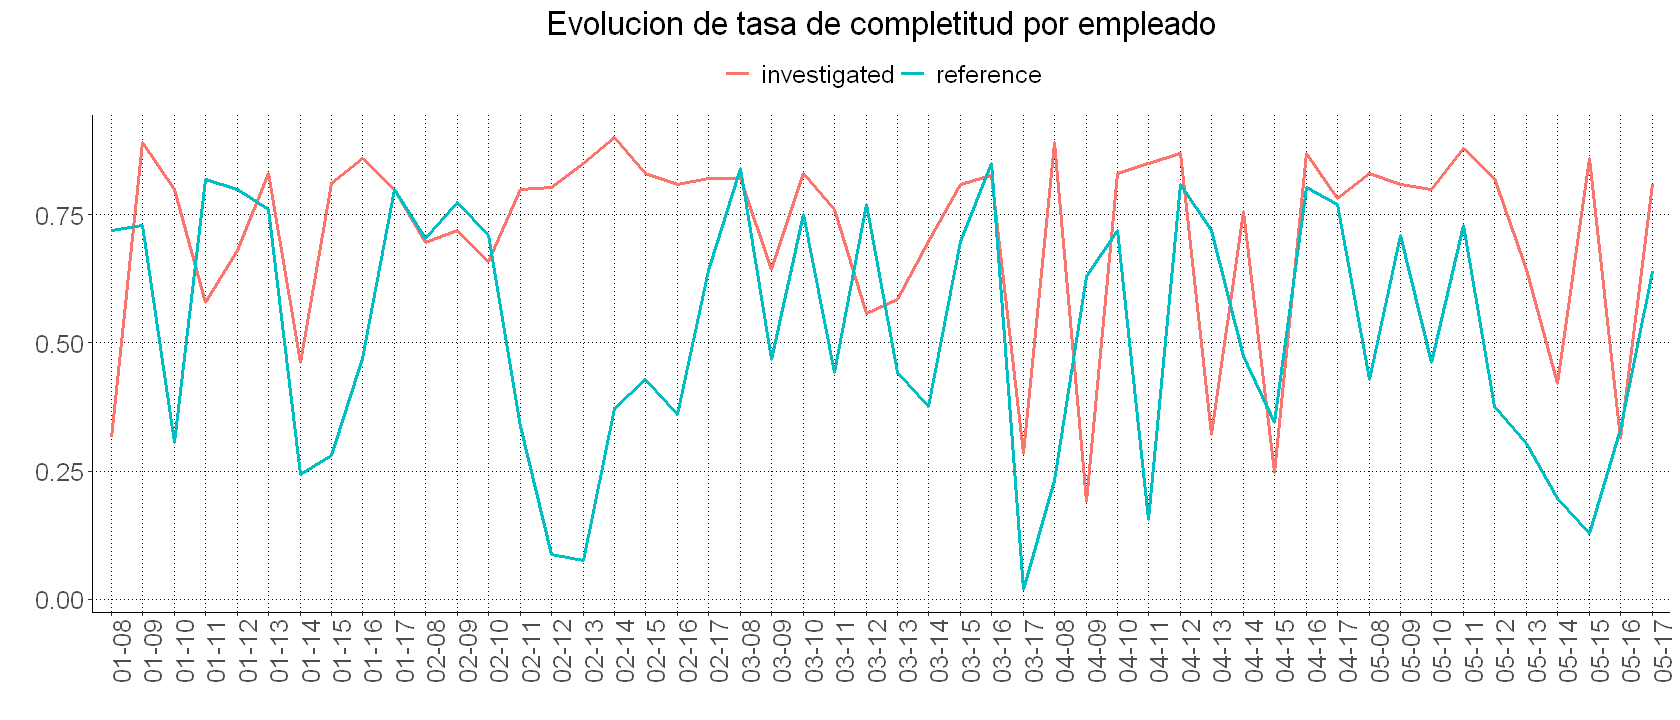

In [25]:
options(repr.plot.width = 14, repr.plot.height = 6)
ggplot(
    data = df_consolidado,
    mapping = aes(
        x = reorder(dayhour, nday),
        y = completed_calls_rate,
        color = employee,
        group = employee
    )
) +
geom_line(
    linewidth = 1
) +
labs(
    title = "Evolucion de tasa de completitud por empleado",
    x = "",
    y = ""
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.text.x = element_text(angle = 90),
    axis.title = element_text(size = 15),
    legend.title = element_blank(),
    legend.text = element_text(size = 15),
    legend.position = "top"
)

Estos resultados evidenciarían que el operador investigado en efecto tiene mejor rendimiento en cuanto a completitud de llamadas. Sin embargo, al tener solamente información de la última semana necesitamos aplicar métodos de inferencia para poder generalizar estas conclusiones. 

## Análisis exploratorio inferencial

Como ya se mencionó, vamos a utilizar **test de hipótesis** e **intervalos de confianza** como métodos estadísticos para realizar **pruebas A/B**, las cuales nos permitan validar hipótesis derivadas del analisis descriptivo realizado previamente. 

### Prueba A/B para variabilidad

Comencemos por tanto estudiando la variabilidad de los minutos activos en el CRM. Si recuerdas, el colaborador investigado afirmaba que su tiempo de trabajo, si bien podía ser menor al del resto de compañeros, era más estable y homogeneo. Para verificar si tiene razón, inicia planteando el siguiente conjunto de hipótesis de investigación: 

* Nula: aquella que postula que no existen efectos que distingan a ambos grupos.
* Alternativa: aquella que postula que sí existen efectos que diferencian a los grupos. 

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | El empleado investigado tiene IGUAL variabilidad en sus minutos activo que el empleado de referencia. |
| Alternativa | El empleado investigado tiene MENOR variabilidad en sus minutos activo que el empleado de referencia. |

A continuación, extrae las correspondientes muestras de minutos de actividad para los dos grupos de empleados.

In [26]:
# Extraer muestra para empleado investigado
sample_inv <- df_consolidado %>%
filter(employee == "investigated") %>%
pull(minutes_active_in_crm)

# Extraer muestra para empleado referencia
sample_ref <- df_consolidado %>%
filter(employee == "reference") %>%
pull(minutes_active_in_crm)

Para estudiar mediante inferencia las hipótesis planteadas, hay que realizar un test estadístico de donde se extraiga un **valor p**. El valor p hace referencia a la probabilidad teórica de que las diferencias observadas en el indicador estudiado (en este caso, la dispersión medida por la desviación estándar o varianza) se expliquen fundamentalmente por factores aleatorios o ajenos al efecto estudiado (en este caso, el empleado).

En concreto, las siguientes opciones de test están disponibles para contraste de varianzas:

* **Bartlett**: Asume que los datos muestrales distribuyen de forma normal.
* **Levene**: Asume que los datos muestrales NO distribuyen de forma normal.

Dado que del análisis exploratorio se desprende que existe cierta forma normal en la distribución de estas muestras, utiliza un **test de Bartlett** para extraer el valor p asociado mediante la función `bartlett.test`. Considera que este estadístico debe ajustarse al ser un test de "una cola". 

In [27]:
# Extraer valor p de prueba de Bartlett
p_value <- bartlett.test(list(sample_inv, sample_ref))$p.value

# Ajustar valor p para prueba de una cola
if (sd(sample_inv) < sd(sample_ref)) {
    p_value = p_value / 2
} else {
    p_value = 1 - p_value / 2
}

print(paste(
    "Valor p: ", 
    formatC(p_value * 100, format = "f", digits = 1),
    "%",
    sep = ""
))

[1] "Valor p: 4.5%"


Aplica el criterio de decisión de inferencia estadística con un nivel de significancia del 5%.

In [28]:
if (p_value > 0.05) {
    print("Empleado investigado tendría IGUAL volatilidad de minutos que la referencia.")
} else {
    print("Empleado investigado tendría MENOR volatilidad de miutos que la referencia.") 
}

[1] "Empleado investigado tendría MENOR volatilidad de miutos que la referencia."


Mediante la lógica estadística de esta prueba A/B, se podría ratificar lo argumentado por el empleado respecto a que su tiempo de actividad es más estable. 

Para tener aún más certeza de esto, genera un intervalo al 95% de confianza de la razón entre las varianzas de ambos grupos. Ten en cuenta que estos indicadores de dos muestras como las estudiadas siguen una distribución $\chi^{2}$ con $n-1$ grados de libertad ($n$ es el tamaño de las muestras); y por consiguiente, la razón entre ellas sigue la distribución $F$. Entonces el intervalo de confianza se define por

$$ \left[ \frac{s_1^2}{s_2^2} \times \frac{1}{F_{c}},\, \frac{s_1^2}{s_2^2} \times \frac{1}{F_{1 - c}} \right] $$

donde $F_c$ y $F_{1-c}$ corresponden a los cuantiles F en las posiciones $100c$% y $100(1-c)$%, respectivamente; y $s_j^2$ representa la varianza muestral del grupo $j$.

In [29]:
# Extraer estadisticos f
conf <- 0.95
df <- length(sample_inv) - 1 # ambas muestras tienen el mismo tamaño
f_lower <- qf(1 - conf, df, df)
f_upper <- qchisq(conf, df, df)

In [30]:
# Calcular intervalo de confianza
lower_bound <- (var(sample_inv) / var(sample_ref)) / f_upper
upper_bound <- (var(sample_inv) / var(sample_ref)) / f_lower
print(paste(
    "IC al 95% para razon de varianzas: [",
    formatC(lower_bound, format = "f", digits = 4),
    ", ",
    formatC(upper_bound, format = "f", digits = 4),
    "]",
    sep = ""
))

[1] "IC al 95% para razon de varianzas: [0.0048, 0.9856]"


Este resultado da cuenta que al 95% de confianza, la varianza del empleado investigado sería a lo más un 99% de aquella del empleado de referencia. o lo que es lo mismo, el primero tendría razón en sus argumentos.

### Prueba A/B para promedios

Procedamos ahora a evaluar si este tiempo es menor en promedio al del resto de operadores de la empresa. Plantea las hipótesis nula y alternativa correspondientes.

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | El empleado investigado tiene IGUAL promedio de minutos activo que el empleado de referencia. |
| Alternativa | El empleado investigado tiene MENOR promedio de minutos activo que el empleado de referencia. |

Dado que ahora vamos a estudiar las medias muestrales, obtén el valor p asociado de un **test t** con la función `t.test`. Considera que del ejercicio anterior se ha verificado que la variabilidad entre los grupos no es igual.

In [31]:
p_value <- t.test(
    sample_inv, sample_ref, 
    var.equal = FALSE, 
    alternative = "less"
)$p.value

print(paste(
    "Valor p: ", 
    formatC(p_value * 100, format = "f", digits = 1),
    "%",
    sep = ""
))

[1] "Valor p: 0.0%"


Aplica el criterio de decisión de inferencia estadística con un nivel de significancia del 5%.

In [32]:
if (p_value > 0.05) {
    print("Empleado investigado tendría IGUAL promedio de minutos que la referencia.")
} else {
    print("Empleado investigado tendría MENOR promedio de minutos que la referencia.") 
}

[1] "Empleado investigado tendría MENOR promedio de minutos que la referencia."


Mediante la lógica estadística de esta prueba A/B, se podría ratificar lo argumentado por la gerencia respecto a que el tiempo de actividad del empleado bajo escrutinio es menor que el de otros colaboradores.

Ratifica esto con la generación de un intervalo de confianza al 95%. Ten en cuenta que las medias y sus diferencias siguen una distribución $t$ de Student con $n-1$ grados de libertad, por lo que dicho intervalo se define por

$$ \left[ (\bar x_1 - \bar x_2) - e \times t_c,\, (\bar x_1 - \bar x_2) + e \times t_c \right] $$

donde $t_c$ es el cuantil t en la posición $100c$%, $\bar x_j$ representa la media muestral del grupo $j$, y $e$ es el error estandar asociado a las diferencias tal que

$$ e = \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}} $$

In [33]:
# Extraer estadistico t
conf <- 0.95
df <- length(sample_inv) - 1 # ambas muestras tienen el mismo tamaño
t_val <- qt(conf, df)

In [34]:
# Calcular error estandar de la diferencia
error <- sqrt((var(sample_inv) / length(sample_inv)) + (var(sample_ref) / length(sample_ref)))

In [35]:
# Calcular intervalo de confianza
lower_bound <- (mean(sample_inv) - mean(sample_ref)) - error * t_val
upper_bound <- (mean(sample_inv) - mean(sample_ref)) + error * t_val
print(paste(
    "IC al 95% para diferencia de medias: [",
    formatC(lower_bound, format = "f", digits = 2),
    ", ",
    formatC(upper_bound, format = "f", digits = 2),
    "]",
    sep = ""
))

[1] "IC al 95% para diferencia de medias: [-13.04, -6.20]"


Se ratifica el resultado obtenido en el test de hipótesis puesto que con un 95% de confianza, el tiempo medio del empleado investigado sería en el mejor de los casos 6 minutos menor al de la referencia. 

### Prueba A/B para proporciones

Queda finalmente verificar si el indicador de completitud de llamadas es mayor para el caso de la persona investigada. Plantea las hipótesis nula y alternativa correspondientes.

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | El empleado investigado tiene IGUAL tasa de llamadas completadas que el empleado de referencia. |
| Alternativa | El empleado investigado tiene MAYOR tasa de llamadas completadas que el empleado de referencia. |

Extrae las muestras de datos correspondientes para esta prueba. 

In [36]:
# Extraer muestra para empleado investigado
sample_inv <- df_consolidado %>%
filter(employee == "investigated") %>%
pull(completed_calls_rate)

# Extraer muestra para empleado referencia
sample_ref <- df_consolidado %>%
filter(employee == "reference") %>%
pull(completed_calls_rate)

Dado que el indicador corresponde a un porcentaje, conviene realizar un **test z de proporciones** para de allí extraer el valor p asociado. Entonces genera un vector atómico que contenga dos valores:

* El primero corresponde a la estimación de llamadas completadas que tendrá el empleado investigado de un total de 100 ejecutadas.
* El segundo corresponde a la estimación de llamadas competadas que tendrá el resto de operadores de un total de 100 ejecutadas.

In [37]:
# Generar vector con exitos por tipo de empleado
mean_inv <- mean(sample_inv)
mean_ref <- mean(sample_ref)
success <- c(as.integer(100 * mean_inv), as.integer(100 * mean_ref))

Utiliza esta lista para realizar la prueba y extraer el valor p asociado. Incorpora por tanto la lista como argumento de la función `prop.test`.

In [38]:
# Obtener valor p
p_value <- prop.test(
    x = success,
    n = c(100, 100),
    alternative = "greater",
    correct = FALSE
)$p.value

print(paste(
    "Valor p: ", 
    formatC(p_value * 100, format = "f", digits = 1),
    "%",
    sep = ""
))

[1] "Valor p: 0.3%"


Aplica el criterio de decisión de inferencia estadística con un nivel de significancia del 5%.

In [39]:
# Aplicar criterio de decision
if (p_value > 0.05) {
    print("Empleado investigado tendría IGUAL tasa de llamadas completadas que la referencia.")
} else {
    print("Empleado investigado tendría MAYOR tasa de llamadas completadas que la referencia.") 
}

[1] "Empleado investigado tendría MAYOR tasa de llamadas completadas que la referencia."


Mediante la lógica estadística de esta prueba A/B, se podría ratificar lo argumentado por el empleado en cuanto su rendimiento medido por tasa de llamadas completadas es mayor.

Finaliza generando un intervalo al 95% confianza respecto a la diferencia de las proporciones. En vista que estamos asumiendo que estas proporciones y sus diferencias siguen una distribución normal estandar, se tiene que dicho intervalo se define por 

$$ \left[ (\hat p_1 - \hat p_2) - e\times z_c, \, (\hat p_1 - \hat p_2) + e\times z_c\right] $$

donde $z_c$ es el cuantil z en la posición $100c$%, $\hat p_j$ es la proporción muestral de referencia de $j$, y $e$ es el error estandar definido por

$$ e = \sqrt{\frac{\hat p_1(1 - \hat p_1)}{n_1} + \frac{\hat p_2(1 - \hat p_2)}{n_2}} $$


In [40]:
# Extraer estadistico z
conf <- 0.95
z_val <- qnorm(conf)

In [41]:
# Calcular error estandar de la diferencia
error <- sqrt((mean_inv * (1 - mean_inv) / length(sample_inv)) + (mean_ref * (1 - mean_ref) / length(sample_ref)))

In [42]:
# Calcular intervalo de confianza
lower_bound <- (mean_inv - mean_ref) - error * z_val
upper_bound <- (mean_inv - mean_ref) + error * z_val
print(paste(
    "IC al 95% para diferencia de proporciones: [",
    formatC(lower_bound * 100, format = "f", digits = 1),
    "%, ",
    formatC(upper_bound * 100, format = "f", digits = 1),
    "%]",
    sep = ""
))

[1] "IC al 95% para diferencia de proporciones: [3.3%, 34.7%]"


Se ratifica el resultado obtenido en el test de hipótesis puesto que con un 95% de confianza, la tasa de llamadas completadas por parte del investigado sería en el peor escenario 3 puntos porcentuales mayor al de la referencia. 

Genera una conclusión adecuada a brindar a la empresa y que le permita tomar una decisión justa y adecuada en esta caso.

| # | Conclusión |
| ---- | ---- |
| 1 | Si bien el empleado investigado trabaja menos tiempo que los demás miembros del equipo, durante este tiempo su trabajo es más estable y con mejores resultados en cuanto a llamadas completadas. Por lo expuesto, se recomienda no proceder con la solicitud de desvinculación dado que la persona se ha mostrado como alguien eficiente y beneficioso para la organización. | 